In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q datasets PyYAML

In [3]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK3_WORK_ROOT = (
    PROJECT_ROOT / "task3"
)

TASK3_REPO_ROOT = (
    REPO_ROOT / "task3"
)

PACS_ROOT = (
    PROJECT_ROOT / "datasets/PACS"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Change the Colab runtime to GPU."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

Device: cuda
GPU: Tesla T4


In [5]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import json

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml

from datasets import load_from_disk

from common.seed import set_seed

from shared.pacs_protocol import (
    load_pacs_protocol,
)

from task2.evaluation.source_validation import (
    evaluate_source_domains,
)

from task2.models.classifier_head import (
    PACSClassifier,
)

from task2.selection.checkpointing import (
    SourceValidationSelector,
)

from task3.data.source_loaders import (
    build_task3_source_datasets,
    build_task3_source_loaders,
)

from task3.train import (
    train_task3_method,
)


SEED = 6304

set_seed(SEED)

with (
    TASK3_REPO_ROOT
    / "configs/base.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    base_config = yaml.safe_load(
        config_file
    )

with (
    TASK3_REPO_ROOT
    / "configs/controlled_study.yaml"
).open(
    "r",
    encoding="utf-8",
) as config_file:
    controlled_config = yaml.safe_load(
        config_file
    )

print("Controlled-study configuration:")

print(
    yaml.safe_dump(
        controlled_config,
        sort_keys=False,
    )
)

print(
    "Selection data:",
    controlled_config[
        "study"
    ]["selection_data"],
)

print(
    "Target results used to choose study:",
    controlled_config[
        "study"
    ][
        "target_results_used_to_choose_study"
    ],
)

/content/drive/MyDrive/ATML/PA1-repo
Controlled-study configuration:
study:
  method: dan_dg
  parameter: mmd_weight
  values:
  - 0.1
  - 1.0
  - 10.0
  main_comparison_value: 1.0
  selection_data: source_validation_only
  target_results_used_to_choose_study: false
preregistered_expectation:
  source_domain_separability: Expected to decrease as MMD weight increases.
  source_classification: Excessive alignment may remove class information.
  unseen_target_performance: Not assumed to improve monotonically with alignment.

Selection data: source_validation_only
Target results used to choose study: False


In [7]:
pacs_dataset = load_from_disk(
    str(PACS_ROOT)
)

PACS_SPLIT_PATH = (
    REPO_ROOT
    / "shared/splits/"
    "pacs_sketch_seed6304.json"
)

pacs_protocol = load_pacs_protocol(
    PACS_SPLIT_PATH
)

source_datasets = (
    build_task3_source_datasets(
        dataset=pacs_dataset,
        protocol=pacs_protocol,
    )
)

source_loaders = (
    build_task3_source_loaders(
        datasets=source_datasets,
        source_batch_size=8,
        evaluation_batch_size=64,
        number_of_workers=0,
        seed=SEED,
    )
)

print(
    "Source domains:",
    list(
        source_loaders[
            "source_train"
        ].keys()
    ),
)

print(
    "Steps per epoch:",
    source_loaders[
        "steps_per_epoch"
    ],
)

print(
    "Reserved target domain:",
    pacs_protocol[
        "target_domain"
    ],
)

print(
    "Target loader created:",
    "target_adaptation"
    in source_loaders,
)

Source domains: ['photo', 'art_painting', 'cartoon']
Steps per epoch: 234
Reserved target domain: sketch
Target loader created: False


In [8]:
study_weights = [
    0.1,
    10.0,
]

main_history_path = (
    TASK3_REPO_ROOT
    / "results/dan_dg_training_history.csv"
)

main_validation_path = (
    TASK3_REPO_ROOT
    / "results/dan_dg_source_validation.csv"
)

print(
    "Additional weights:",
    study_weights,
)

print(
    "Main lambda=1 history exists:",
    main_history_path.exists(),
)

print(
    "Main lambda=1 validation exists:",
    main_validation_path.exists(),
)

Additional weights: [0.1, 10.0]
Main lambda=1 history exists: True
Main lambda=1 validation exists: True


In [9]:
def run_dan_dg_setting(
    mmd_weight,
):
    set_seed(SEED)

    experiment_loaders = (
        build_task3_source_loaders(
            datasets=source_datasets,
            source_batch_size=8,
            evaluation_batch_size=64,
            number_of_workers=0,
            seed=SEED,
        )
    )

    model = PACSClassifier(
        number_of_classes=7
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=base_config[
            "optimization"
        ]["learning_rate"],
        weight_decay=base_config[
            "optimization"
        ]["weight_decay"],
    )

    weight_name = str(
        mmd_weight
    ).replace(
        ".",
        "p",
    )

    checkpoint_path = (
        TASK3_WORK_ROOT
        / "checkpoints"
        / (
            f"dan_dg_lambda_"
            f"{weight_name}_best.pt"
        )
    )

    selector = SourceValidationSelector(
        checkpoint_path=checkpoint_path,
        patience=base_config[
            "optimization"
        ][
            "early_stopping_patience"
        ],
    )

    print()
    print("=" * 70)

    print(
        "Training DAN-DG with "
        f"MMD weight = {mmd_weight}"
    )

    print("=" * 70)

    training_result = (
        train_task3_method(
            method_name="dan_dg",
            model=model,
            loaders=experiment_loaders,
            optimizer=optimizer,
            selector=selector,
            device=DEVICE,
            maximum_epochs=base_config[
                "optimization"
            ]["maximum_epochs"],
            mmd_weight=mmd_weight,
            gradient_clip_norm=(
                base_config[
                    "optimization"
                ][
                    "gradient_clip_norm"
                ]
            ),
            number_of_classes=7,
        )
    )

    selected_model = (
        training_result["model"]
    )

    history = (
        training_result["history"]
    )

    selected_checkpoint = (
        training_result[
            "selected_checkpoint"
        ]
    )

    validation_results = (
        evaluate_source_domains(
            model=selected_model,
            validation_loaders=(
                experiment_loaders[
                    "source_validation"
                ]
            ),
            device=DEVICE,
            number_of_classes=7,
        )
    )

    history_path = (
        TASK3_REPO_ROOT
        / "results"
        / (
            f"dan_dg_lambda_"
            f"{weight_name}_"
            "training_history.csv"
        )
    )

    history.to_csv(
        history_path,
        index=False,
    )

    validation_rows = []

    for domain_name, metrics in (
        validation_results[
            "domains"
        ].items()
    ):
        validation_rows.append(
            {
                "method": "dan_dg",
                "mmd_weight": (
                    mmd_weight
                ),
                "domain": domain_name,
                "accuracy": (
                    metrics["accuracy"]
                ),
                "macro_f1": (
                    metrics["macro_f1"]
                ),
                "loss": metrics["loss"],
                "number_of_samples": (
                    metrics[
                        "number_of_samples"
                    ]
                ),
            }
        )

    validation_table = pd.DataFrame(
        validation_rows
    )

    validation_path = (
        TASK3_REPO_ROOT
        / "results"
        / (
            f"dan_dg_lambda_"
            f"{weight_name}_"
            "source_validation.csv"
        )
    )

    validation_table.to_csv(
        validation_path,
        index=False,
    )

    print()
    print(
        "Selected epoch:",
        selected_checkpoint["epoch"],
    )

    print(
        "Selected mean source macro-F1:",
        selected_checkpoint[
            "selection_score"
        ],
    )

    return {
        "mmd_weight": mmd_weight,
        "history": history,
        "validation_table": (
            validation_table
        ),
        "validation_results": (
            validation_results
        ),
        "selected_checkpoint": (
            selected_checkpoint
        ),
        "checkpoint_path": (
            checkpoint_path
        ),
    }

In [10]:
controlled_runs = {}

for mmd_weight in study_weights:
    controlled_runs[
        mmd_weight
    ] = run_dan_dg_setting(
        mmd_weight=mmd_weight
    )

print()
print(
    "Completed weights:",
    list(
        controlled_runs.keys()
    ),
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s]



Training DAN-DG with MMD weight = 0.1


dan_dg epoch 1:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 1: train loss=0.5395, mean validation macro-F1=0.8881, best=0.8881


...

Epoch 5: train loss=7.4101, mean validation macro-F1=0.0507, best=0.0507


dan_dg epoch 6:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 6: train loss=6.9683, mean validation macro-F1=0.0507, best=0.0507


dan_dg epoch 7:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 7: train loss=7.4628, mean validation macro-F1=0.0507, best=0.0507
Early stopping triggered.

Selected epoch: 2
Selected mean source macro-F1: 0.05066996495567924

Completed weights: [0.1, 10.0]


In [11]:
main_history = pd.read_csv(
    main_history_path
)

main_validation_table = pd.read_csv(
    main_validation_path
)

main_validation_table[
    "mmd_weight"
] = 1.0

main_best_row = main_history.loc[
    main_history[
        "mean_source_validation_macro_f1"
    ].idxmax()
]

summary_rows = [
    {
        "mmd_weight": 1.0,
        "selected_epoch": int(
            main_best_row["epoch"]
        ),
        "mean_source_accuracy": (
            main_validation_table[
                "accuracy"
            ].mean()
        ),
        "mean_source_macro_f1": (
            main_validation_table[
                "macro_f1"
            ].mean()
        ),
        "worst_source_accuracy": (
            main_validation_table[
                "accuracy"
            ].min()
        ),
        "worst_source_macro_f1": (
            main_validation_table[
                "macro_f1"
            ].min()
        ),
    }
]

validation_tables = [
    main_validation_table
]

for mmd_weight, run_result in (
    controlled_runs.items()
):
    aggregate = run_result[
        "validation_results"
    ]["aggregate"]

    summary_rows.append(
        {
            "mmd_weight": (
                mmd_weight
            ),
            "selected_epoch": int(
                run_result[
                    "selected_checkpoint"
                ]["epoch"]
            ),
            "mean_source_accuracy": (
                aggregate[
                    "mean_accuracy"
                ]
            ),
            "mean_source_macro_f1": (
                aggregate[
                    "mean_macro_f1"
                ]
            ),
            "worst_source_accuracy": (
                aggregate[
                    "worst_accuracy"
                ]
            ),
            "worst_source_macro_f1": (
                aggregate[
                    "worst_macro_f1"
                ]
            ),
        }
    )

    validation_tables.append(
        run_result[
            "validation_table"
        ]
    )

controlled_summary = (
    pd.DataFrame(
        summary_rows
    )
    .sort_values(
        "mmd_weight"
    )
    .reset_index(
        drop=True
    )
)

controlled_validation = pd.concat(
    validation_tables,
    ignore_index=True,
)

summary_path = (
    TASK3_REPO_ROOT
    / "results/"
    "dan_dg_controlled_study_summary.csv"
)

validation_path = (
    TASK3_REPO_ROOT
    / "results/"
    "dan_dg_controlled_study_source_validation.csv"
)

controlled_summary.to_csv(
    summary_path,
    index=False,
)

controlled_validation.to_csv(
    validation_path,
    index=False,
)

print(
    "Controlled-study summary:"
)

print(
    controlled_summary.to_string(
        index=False
    )
)

best_setting = controlled_summary.loc[
    controlled_summary[
        "mean_source_macro_f1"
    ].idxmax()
]

print()
print(
    "Best source-validation setting:",
    best_setting["mmd_weight"],
)

Controlled-study summary:
 mmd_weight  selected_epoch  mean_source_accuracy  mean_source_macro_f1  worst_source_accuracy  worst_source_macro_f1
        0.1              13              0.947228              0.948539               0.904878               0.908774
        1.0               1              0.216568              0.050670               0.172708               0.042078
       10.0               2              0.216568              0.050670               0.172708               0.042078

Best source-validation setting: 0.1


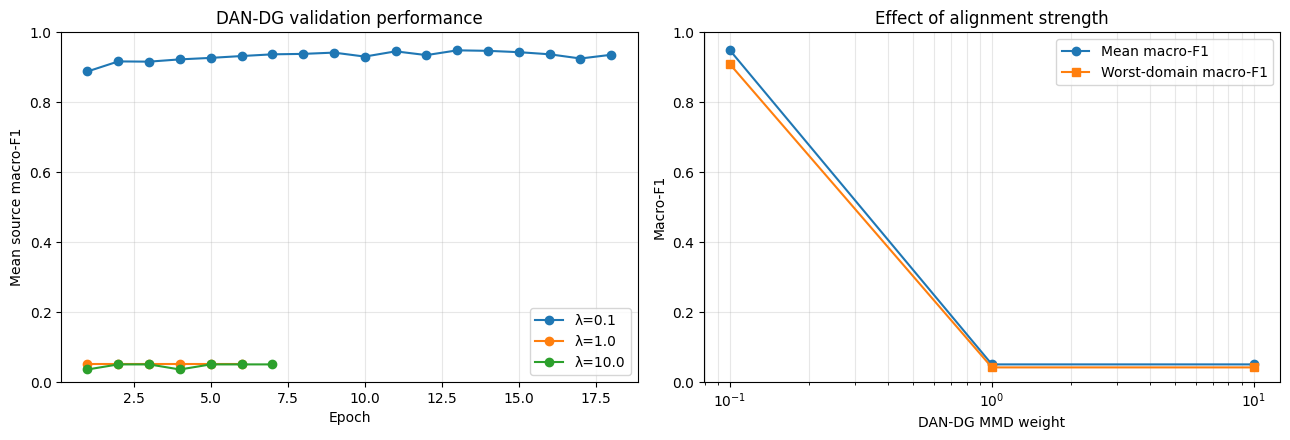

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/figures/dan_dg_controlled_study.png


In [12]:
history_by_weight = {
    0.1: controlled_runs[
        0.1
    ]["history"],
    1.0: main_history,
    10.0: controlled_runs[
        10.0
    ]["history"],
}

figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
)

for mmd_weight, history in (
    history_by_weight.items()
):
    axes[0].plot(
        history["epoch"],
        history[
            "mean_source_validation_macro_f1"
        ],
        marker="o",
        label=(
            f"λ={mmd_weight}"
        ),
    )

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel(
    "Mean source macro-F1"
)
axes[0].set_title(
    "DAN-DG validation performance"
)
axes[0].set_ylim(0.0, 1.0)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    controlled_summary[
        "mmd_weight"
    ],
    controlled_summary[
        "mean_source_macro_f1"
    ],
    marker="o",
    label="Mean macro-F1",
)

axes[1].plot(
    controlled_summary[
        "mmd_weight"
    ],
    controlled_summary[
        "worst_source_macro_f1"
    ],
    marker="s",
    label="Worst-domain macro-F1",
)

axes[1].set_xscale("log")
axes[1].set_xlabel(
    "DAN-DG MMD weight"
)
axes[1].set_ylabel("Macro-F1")
axes[1].set_title(
    "Effect of alignment strength"
)
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(
    alpha=0.3,
    which="both",
)
axes[1].legend()

figure.tight_layout()

figure_path = (
    TASK3_REPO_ROOT
    / "figures/"
    "dan_dg_controlled_study.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [13]:
controlled_metadata = {
    "study_method": "dan_dg",
    "parameter": "mmd_weight",
    "tested_values": [
        0.1,
        1.0,
        10.0,
    ],
    "main_comparison_value": 1.0,
    "best_source_validation_value": float(
        best_setting[
            "mmd_weight"
        ]
    ),
    "selection_data": (
        "source_validation_only"
    ),
    "target_images_loaded": False,
    "target_labels_used": False,
    "target_results_used_to_choose_study": False,
    "results": [
        {
            "mmd_weight": float(
                row["mmd_weight"]
            ),
            "selected_epoch": int(
                row["selected_epoch"]
            ),
            "mean_source_accuracy": float(
                row[
                    "mean_source_accuracy"
                ]
            ),
            "mean_source_macro_f1": float(
                row[
                    "mean_source_macro_f1"
                ]
            ),
            "worst_source_accuracy": float(
                row[
                    "worst_source_accuracy"
                ]
            ),
            "worst_source_macro_f1": float(
                row[
                    "worst_source_macro_f1"
                ]
            ),
        }
        for _, row
        in controlled_summary.iterrows()
    ],
}

metadata_path = (
    TASK3_REPO_ROOT
    / "results/"
    "dan_dg_controlled_study_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        controlled_metadata,
        metadata_file,
        indent=2,
    )

print(
    json.dumps(
        controlled_metadata,
        indent=2,
    )
)

{
  "study_method": "dan_dg",
  "parameter": "mmd_weight",
  "tested_values": [
    0.1,
    1.0,
    10.0
  ],
  "main_comparison_value": 1.0,
  "best_source_validation_value": 0.1,
  "selection_data": "source_validation_only",
  "target_images_loaded": false,
  "target_labels_used": false,
  "target_results_used_to_choose_study": false,
  "results": [
    {
      "mmd_weight": 0.1,
      "selected_epoch": 13,
      "mean_source_accuracy": 0.9472282020804198,
      "mean_source_macro_f1": 0.9485386903304263,
      "worst_source_accuracy": 0.9048780487804878,
      "worst_source_macro_f1": 0.9087739996031188
    },
    {
      "mmd_weight": 1.0,
      "selected_epoch": 1,
      "mean_source_accuracy": 0.21656837139595678,
      "mean_source_macro_f1": 0.05066996495567919,
      "worst_source_accuracy": 0.1727078891257995,
      "worst_source_macro_f1": 0.042077922077922
    },
    {
      "mmd_weight": 10.0,
      "selected_epoch": 2,
      "mean_source_accuracy": 0.21656837139595686,
